# 2. Iris 데이터 K-Means 군집화

군집화(clustering)는 소속 집단 정보 없이 비슷한 집단으로 묶는 비지도 학습이다.  
KNN(분류)과 달리 정답 레이블을 쓰지 않는다는 게 핵심 차이.  
여기서는 Iris 4개 피처만으로 k=3 군집을 만들고, 실제 품종과 얼마나 일치하는지 비교해본다.

## 1. 패키지

In [1]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

## 2. 데이터 준비

군집화는 target을 학습에 쓰지 않는다 — 평가할 때만 참고용으로 사용

In [2]:
iris = load_iris()

FEATURES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
COLORS   = {'Setosa': '#E74C3C', 'Versicolor': '#3498DB', 'Virginica': '#2ECC71'}

df = pd.DataFrame(iris.data, columns=FEATURES)
df['species']      = iris.target
df['species_name'] = df['species'].map({0:'Setosa', 1:'Versicolor', 2:'Virginica'})

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
species_name    0
dtype: int64

In [5]:
df['species_name'].value_counts()

species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

## 3. EDA

군집화 전에 데이터 분포를 파악해둔다.  
어떤 피처가 군집을 잘 나눌 수 있는지 미리 확인하는 과정.

In [6]:
# 왜도 / 첨도 / IQR 이상치
stat = pd.DataFrame({
    'mean':     df[FEATURES].mean(),
    'std':      df[FEATURES].std(),
    'skewness': df[FEATURES].skew(),
    'kurtosis': df[FEATURES].kurtosis(),
}).round(3)

outlier_cnt = {}
for f in FEATURES:
    Q1, Q3 = df[f].quantile(0.25), df[f].quantile(0.75)
    IQR = Q3 - Q1
    outlier_cnt[f] = int(((df[f] < Q1-1.5*IQR) | (df[f] > Q3+1.5*IQR)).sum())
stat['outliers(IQR)'] = pd.Series(outlier_cnt)

print(stat)

               mean    std  skewness  kurtosis  outliers(IQR)
sepal_length  5.843  0.828     0.315    -0.552              0
sepal_width   3.057  0.436     0.319     0.228              4
petal_length  3.758  1.765    -0.275    -1.402              0
petal_width   1.199  0.762    -0.103    -1.341              0


In [7]:
df.groupby('species_name')[FEATURES].mean().round(3)

,sepal_length,sepal_width,petal_length,petal_width
species_name,,,,
Setosa,5.006,3.428,1.462,0.246
Versicolor,5.936,2.770,4.260,1.326
Virginica,6.588,2.974,5.552,2.026


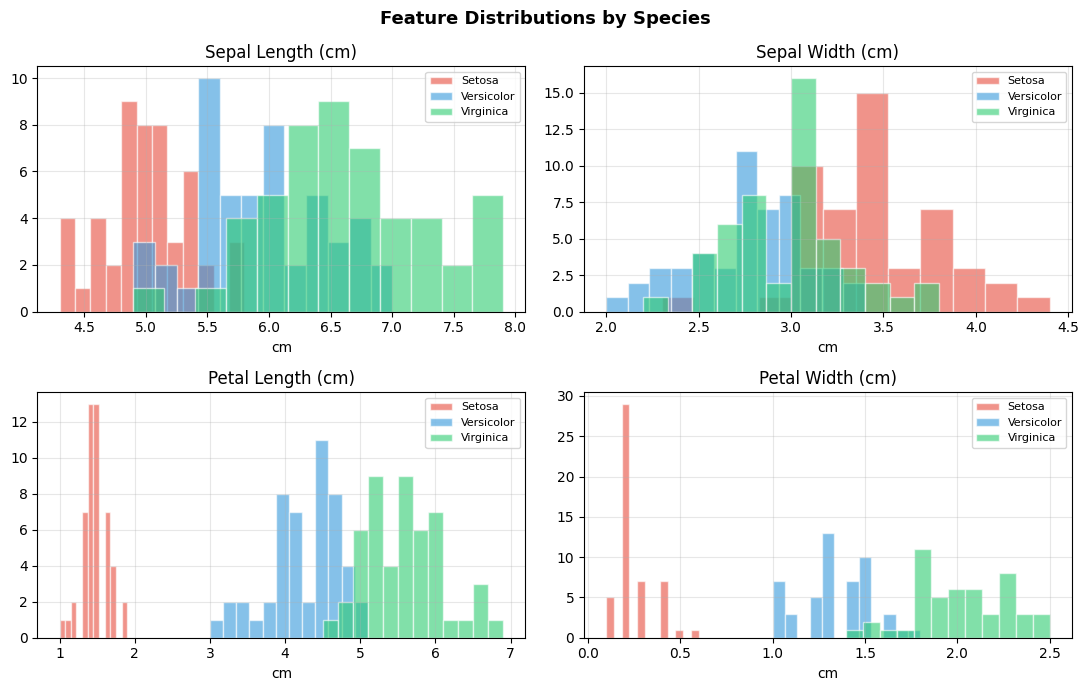

In [8]:
# 히스토그램
labels = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat, label in zip(axes.flatten(), FEATURES, labels):
    for sp, color in COLORS.items():
        ax.hist(df[df['species_name']==sp][feat], bins=12,
                alpha=0.6, color=color, label=sp, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('cm')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Feature Distributions by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# petal 쪽은 품종간 분리가 확실하고, sepal_width는 많이 겹침

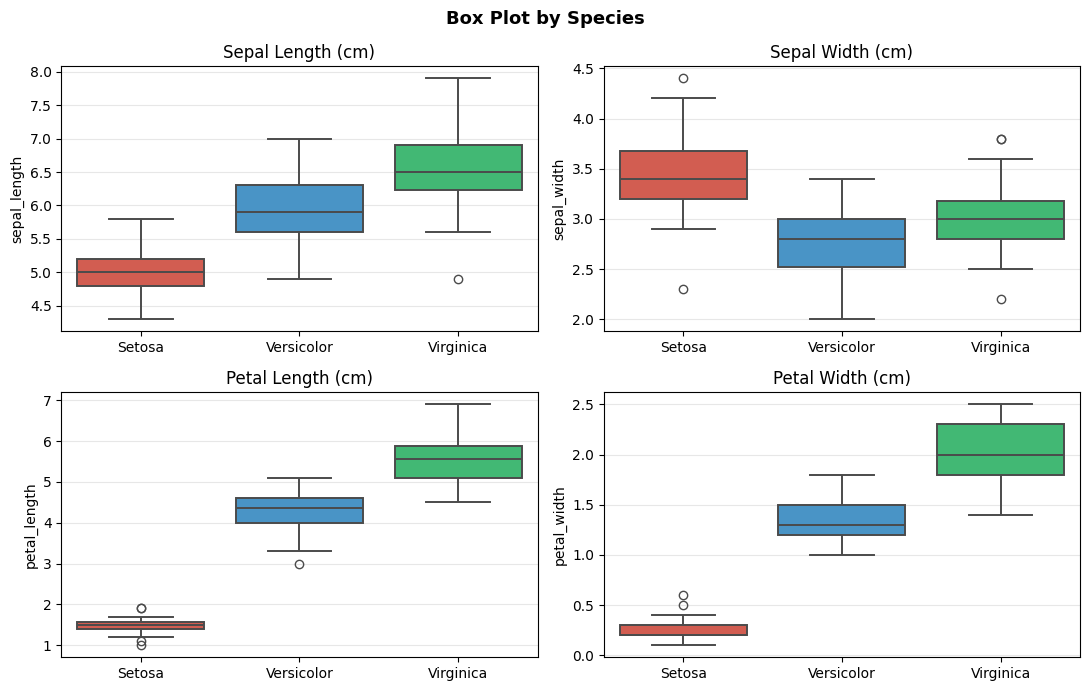

In [9]:
# 박스플롯
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat, label in zip(axes.flatten(), FEATURES, labels):
    sns.boxplot(
        data=df, x='species_name', y=feat,
        hue='species_name', palette=COLORS,
        order=['Setosa','Versicolor','Virginica'],
        legend=False, linewidth=1.4, ax=ax
    )
    ax.set_title(label)
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Box Plot by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# sepal_width에 이상치 존재 — IQR 기준 4개

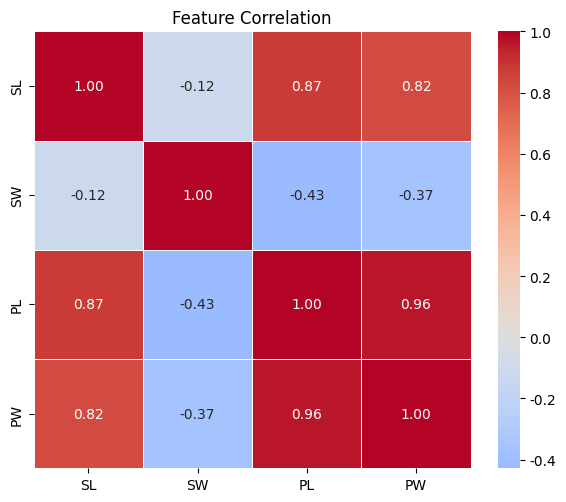

petal_length <-> petal_width: 0.963
sepal_width  <-> petal_length: -0.428


In [10]:
# 상관관계 히트맵
corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5,
            xticklabels=['SL','SW','PL','PW'],
            yticklabels=['SL','SW','PL','PW'], ax=ax)
ax.set_title('Feature Correlation', fontsize=12)
plt.tight_layout()
plt.show()

print(f'petal_length <-> petal_width: {corr.loc["petal_length","petal_width"]:.3f}')
print(f'sepal_width  <-> petal_length: {corr.loc["sepal_width","petal_length"]:.3f}')

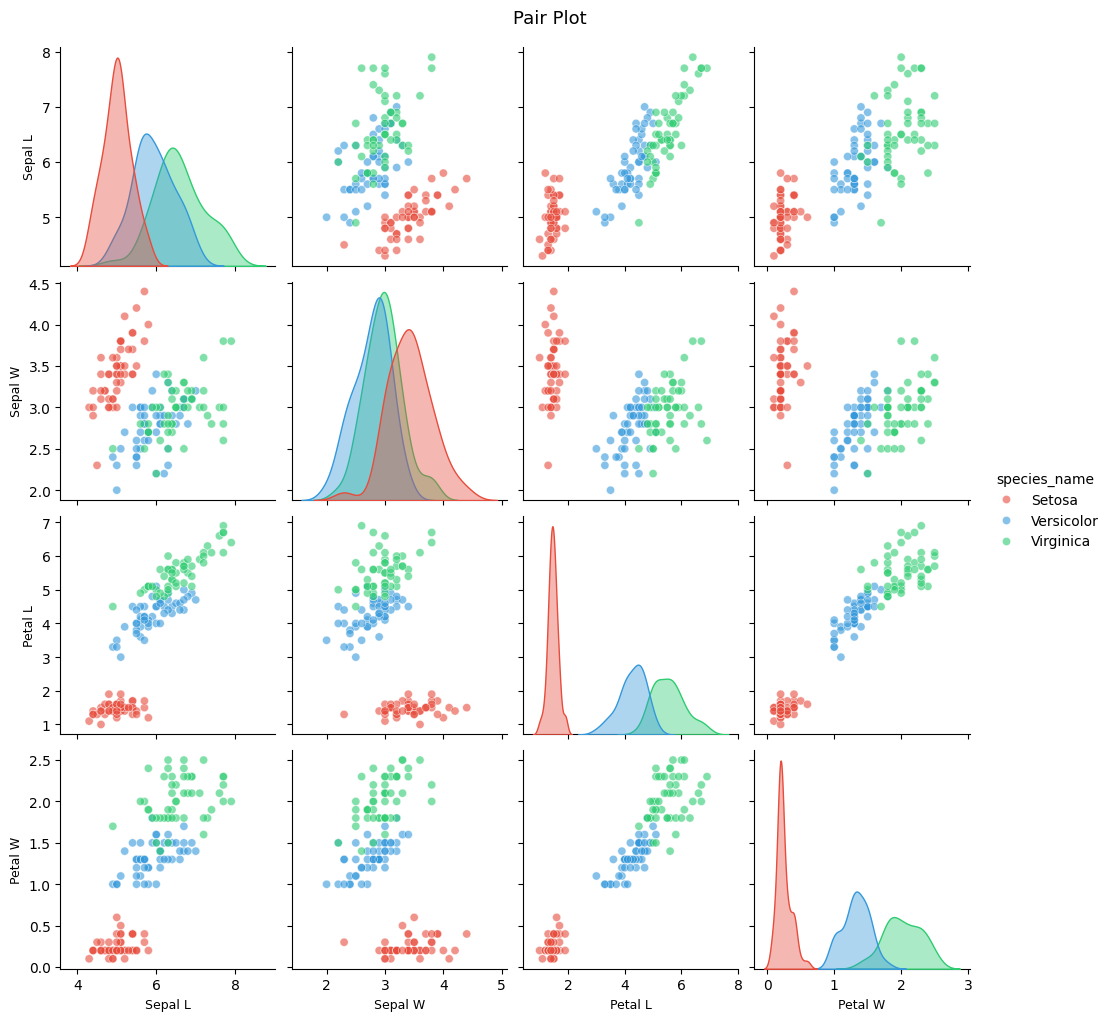

In [11]:
# 페어플롯
pair = sns.pairplot(
    df[FEATURES + ['species_name']],
    hue='species_name', palette=COLORS,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 35, 'edgecolor': 'white'},
    diag_kws={'fill': True, 'alpha': 0.4}
)
pair.figure.suptitle('Pair Plot', y=1.02, fontsize=13)

short = ['Sepal L','Sepal W','Petal L','Petal W']
for i, ax in enumerate(pair.axes[-1]): ax.set_xlabel(short[i], fontsize=9)
for i, ax in enumerate(pair.axes[:,0]): ax.set_ylabel(short[i], fontsize=9)

plt.show()

# Setosa는 어떤 조합에서도 분리가 잘 됨
# Versicolor, Virginica는 petal 피처 조합에서 그나마 구분 가능

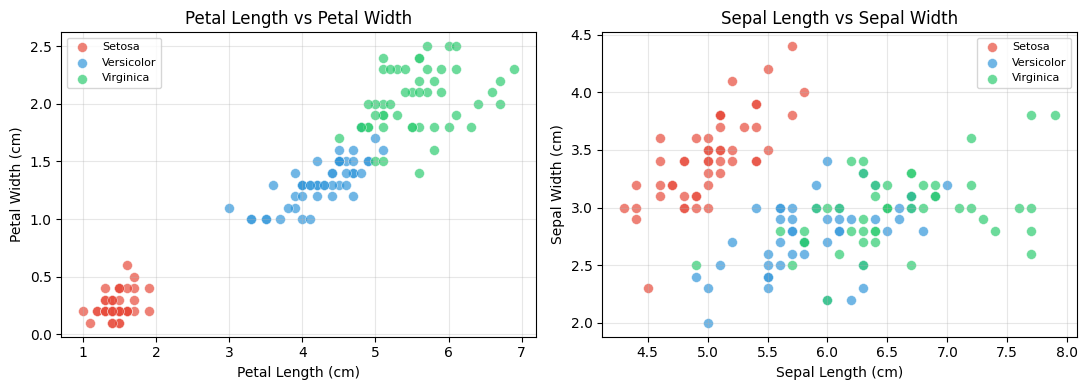

In [12]:
# 핵심 피처 산포도
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (xf, yf, title) in zip(axes, [
    ('petal_length', 'petal_width', 'Petal Length vs Petal Width'),
    ('sepal_length', 'sepal_width', 'Sepal Length vs Sepal Width'),
]):
    for sp, color in COLORS.items():
        sub = df[df['species_name']==sp]
        ax.scatter(sub[xf], sub[yf], c=color, label=sp,
                   alpha=0.7, s=50, edgecolors='white', linewidth=0.4)
    ax.set_title(title)
    ax.set_xlabel(xf.replace('_',' ').title() + ' (cm)')
    ax.set_ylabel(yf.replace('_',' ').title() + ' (cm)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 피처 스케일링

K-Means도 거리 기반 — 스케일 차이에 민감하므로 StandardScaler 적용

In [13]:
X = df[FEATURES].values
y = df['species'].values   # 군집화에는 안 쓰고 평가할 때만 씀

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print('스케일링 후 평균:', X_std.mean(axis=0).round(4))
print('스케일링 후 표준편차:', X_std.std(axis=0).round(4))

스케일링 후 평균: [-0. -0. -0. -0.]
스케일링 후 표준편차: [1. 1. 1. 1.]


## 5. 최적 k 탐색 — Elbow Method

K-Means는 k를 미리 정해야 한다.  
Inertia(군집 내 거리 합)가 꺾이는 지점을 보고 k를 선택한다 — Elbow Method

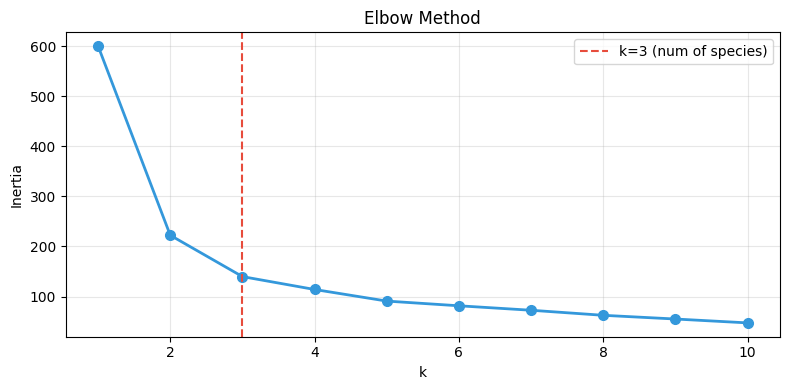

In [14]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_std)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, 'o-', color='#3498DB', lw=2, ms=7)
ax.axvline(3, color='#E74C3C', linestyle='--', lw=1.5, label='k=3 (num of species)')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# k=3 부근에서 꺾임 → 실제 품종 수 3개와 일치

## 6. K-Means 군집화

k-평균 알고리즘은 단순하고 직관적이다.
- k개 중심점 임의 초기화
- 각 데이터를 가장 가까운 중심점에 배정
- 군집 내 평균으로 중심점 갱신
- 중심점이 변하지 않을 때까지 반복

단점은 k를 미리 지정해야 한다는 것과, 초기화에 따라 결과가 달라질 수 있다는 점

In [15]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(X_std)

labels = km.predict(X_std)
print('군집 결과 labels:', labels)
print('\n군집별 샘플 수:', np.bincount(labels))

군집 결과 labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]

군집별 샘플 수: [53 50 47]


In [16]:
# 군집화는 레이블 번호에 품종 의미가 없음 → 실제 품종과 매핑해서 new_label 생성
# 각 군집에서 가장 많은 품종으로 대응
df['cluster'] = labels

label_map = {}
for cluster_id in range(3):
    mask = df['cluster'] == cluster_id
    dominant = df.loc[mask, 'species'].mode()[0]
    label_map[cluster_id] = dominant

print('군집 -> 품종 매핑:', label_map)
df['new_label'] = df['cluster'].map(label_map)
print('\nnew_labels:', df['new_label'].values)

군집 -> 품종 매핑: {0: np.int64(1), 1: np.int64(0), 2: np.int64(2)}

new_labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 1 1 1 2 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1
 1 2 2 2 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 2 2 2 2 2 2 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


## 7. 평가

군집화는 비지도 학습이라 정확도 개념이 엄밀하지 않다.  
여기서는 실제 품종 레이블과 비교해 얼마나 잘 나뉘었는지 참고용으로 확인한다.

In [17]:
acc = accuracy_score(y, df['new_label'])
print(f'군집화 정확도: {acc:.4f}')
print()

cm = confusion_matrix(y, df['new_label'])
print('혼동 행렬:')
print(cm)

군집화 정확도: 0.8333

혼동 행렬:
[[50  0  0]
 [ 0 39 11]
 [ 0 14 36]]


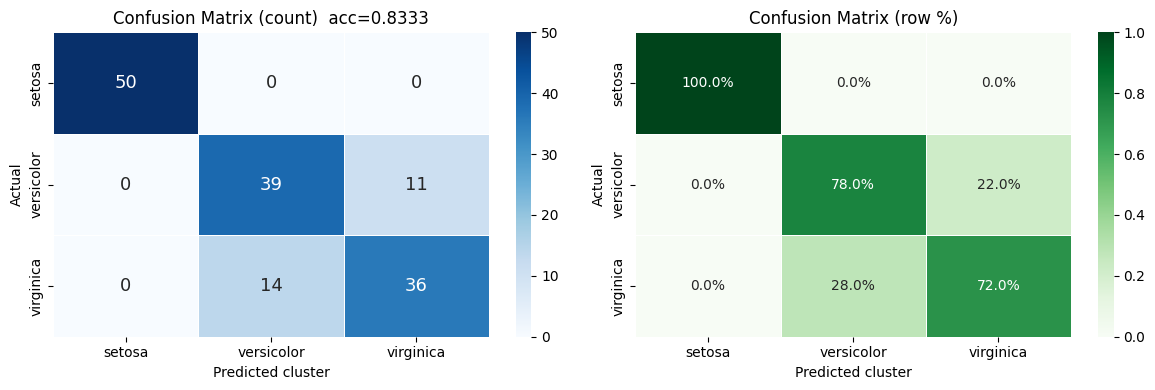

In [18]:
# 혼동 행렬 시각화
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            ax=axes[0], linewidths=0.5, annot_kws={'size':13})
axes[0].set_title(f'Confusion Matrix (count)  acc={acc:.4f}')
axes[0].set_xlabel('Predicted cluster'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (row %)')
axes[1].set_xlabel('Predicted cluster'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

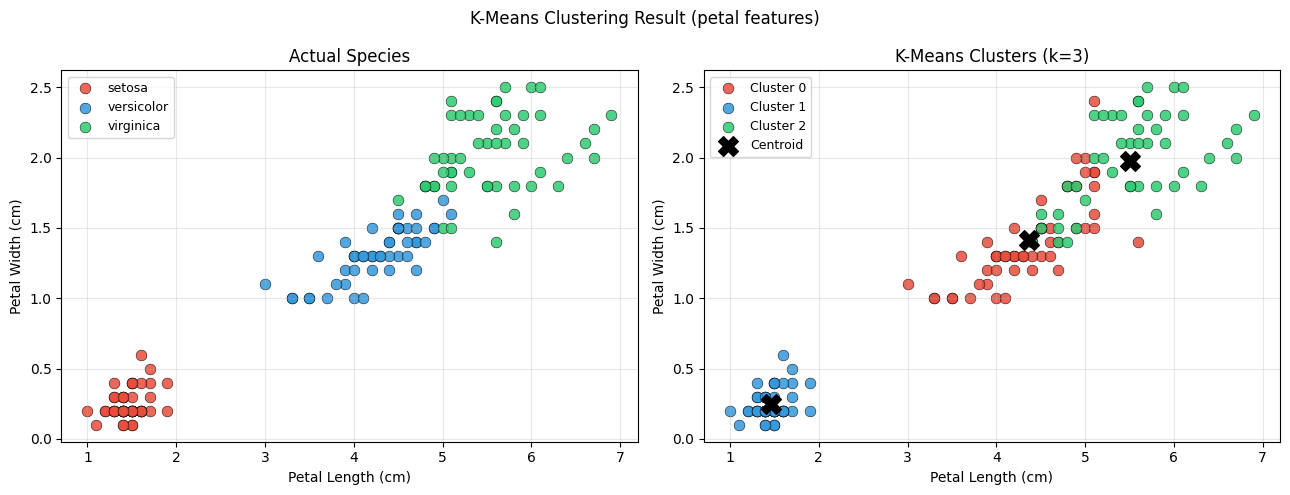

In [19]:
# 군집 결과 시각화 — petal 피처로 확인
CLUSTER_COLORS = ['#E74C3C', '#3498DB', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('K-Means Clustering Result (petal features)', fontsize=12)

# 실제 품종
for label in range(3):
    mask = y == label
    axes[0].scatter(X[mask, 2], X[mask, 3],
                    c=CLUSTER_COLORS[label], label=iris.target_names[label],
                    s=60, edgecolors='black', linewidth=0.4, alpha=0.85)
axes[0].set_title('Actual Species')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# 군집 결과
for c in range(3):
    mask = labels == c
    axes[1].scatter(X[mask, 2], X[mask, 3],
                    c=CLUSTER_COLORS[c], label=f'Cluster {c}',
                    s=60, edgecolors='black', linewidth=0.4, alpha=0.85)

# 중심점 표시
centers_orig = scaler.inverse_transform(km.cluster_centers_)
axes[1].scatter(centers_orig[:, 2], centers_orig[:, 3],
                c='black', marker='X', s=200, zorder=5, label='Centroid')
axes[1].set_title('K-Means Clusters (k=3)')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

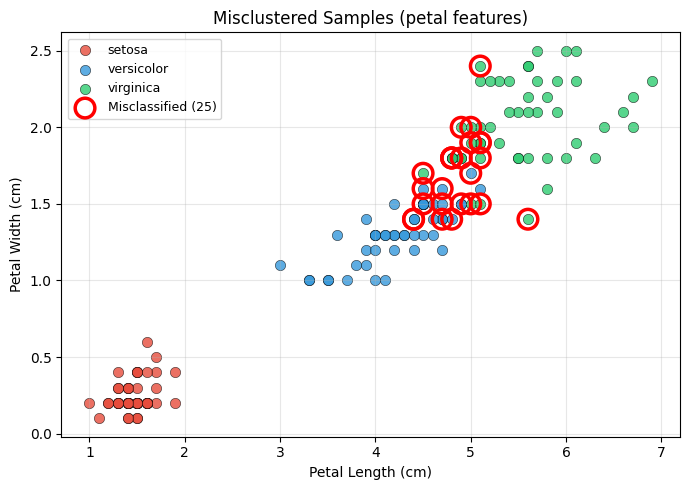

오군집: 25개 / 150개


In [20]:
# 오군집 위치 확인 — 어디서 틀렸는지
wrong = df['new_label'] != df['species']

fig, ax = plt.subplots(figsize=(7, 5))
for label in range(3):
    mask = y == label
    ax.scatter(X[mask, 2], X[mask, 3],
               c=CLUSTER_COLORS[label], label=iris.target_names[label],
               s=55, edgecolors='black', linewidth=0.4, alpha=0.8)

if wrong.sum() > 0:
    ax.scatter(X[wrong, 2], X[wrong, 3],
               s=200, facecolors='none', edgecolors='red',
               linewidth=2.5, zorder=5, label=f'Misclassified ({wrong.sum()})')

ax.set_title('Misclustered Samples (petal features)')
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'오군집: {wrong.sum()}개 / {len(y)}개')

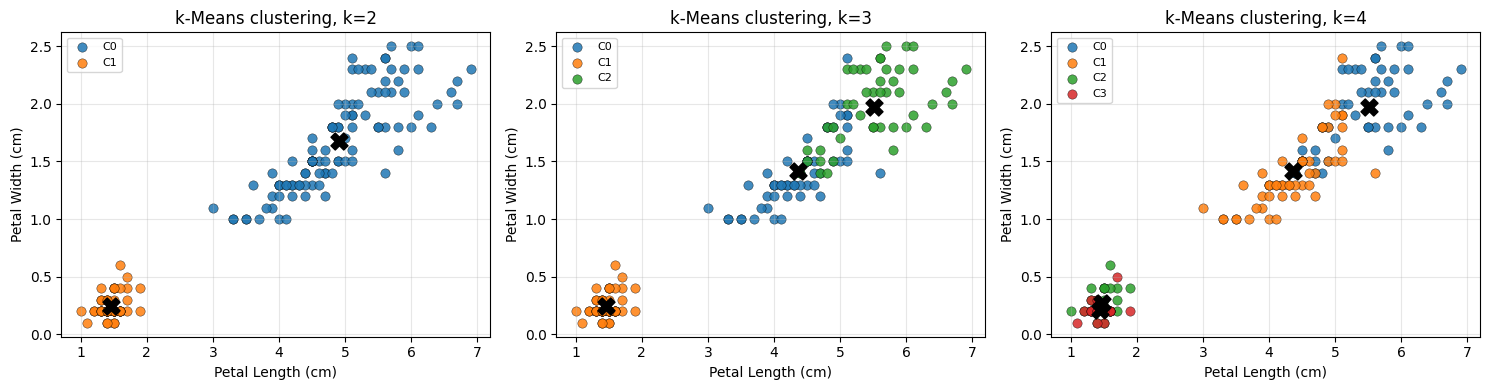

In [21]:
# k=2, 3, 4 군집 결과 비교 (강의 p.46 참고)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, k in zip(axes, [2, 3, 4]):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_k = km_k.fit_predict(X_std)
    centers_k = scaler.inverse_transform(km_k.cluster_centers_)
    
    cmap = matplotlib.colormaps.get_cmap('tab10')
    for c in range(k):
        mask = lbl_k == c
        ax.scatter(X[mask, 2], X[mask, 3],
                   color=cmap(c), s=45, edgecolors='black',
                   linewidth=0.3, alpha=0.85, label=f'C{c}')
    ax.scatter(centers_k[:, 2], centers_k[:, 3],
               c='black', marker='X', s=150, zorder=5)
    ax.set_title(f'k-Means clustering, k={k}')
    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# 최종 정리
print(f'알고리즘  : KMeans')
print(f'k         : 3')
print(f'스케일링  : StandardScaler')
print(f'군집화 정확도: {acc:.4f}')
print(f'오군집    : {wrong.sum()}개 / {len(y)}개')
print()
print('Setosa는 군집이 명확하게 분리됨')
print('Versicolor / Virginica 경계에서 일부 오군집 발생')

알고리즘  : KMeans
k         : 3
스케일링  : StandardScaler
군집화 정확도: 0.8333
오군집    : 25개 / 150개

Setosa는 군집이 명확하게 분리됨
Versicolor / Virginica 경계에서 일부 오군집 발생
